
# Univariate Budget-Matched Sobol vs Midpoint Normalizer Study

This notebook studies a narrow numerical question for univariate HAL density estimation:

- `midpoint_4096` is treated as a **high-resolution numerical reference**.
- For matched budgets `B in {32, 64, 128, 256, 512}`, we compare:
  - midpoint normalization with `B` regular midpoint cells,
  - fixed-bank scrambled Sobol normalization with `B` bank points.
- The training sample, knots, basis construction, one-norm constraint, and solver policy are held fixed.
- The only difference between midpoint and Sobol fits is the normalizer approximation.

The 50-repetition block later in the notebook is a **Sobol bank sensitivity study** on one fixed dataset. It is not a dataset-level simulation study.


In [1]:

import sys
from pathlib import Path

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import trapezoid
from scipy.special import logsumexp
from scipy.stats import qmc

# Ensure repo root is importable when the notebook is opened from nested folders.
root = Path.cwd().resolve()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from src.haldensity.utils import TruncatedNormal, create_basis_functions

np.random.seed(0)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

CONFIG = {
    "n_train": 100,
    "n_valid": 5000,
    "data_seed": 0,
    "basis_order": 1,
    "norm_constraint": 65.0,
    "budgets": [32, 64, 128, 256, 512],
    "reference_grid_points": 4096,
    "representative_seed": 7,
    "rep_seeds": list(range(50)),
    "solver": "ECOS",
    "use_secondary_solver": True,
    "solver_waterfall": ["MOSEK", "CLARABEL", "ECOS", "SCS"],
    "fine_grid_n": 10_000,
    "fine_grid_min": 0.001,
    "fine_grid_max": 0.999,
    "theta_tol": 1e-4,
}

print(CONFIG)


{'n_train': 100, 'n_valid': 5000, 'data_seed': 0, 'basis_order': 1, 'norm_constraint': 65.0, 'budgets': [32, 64, 128, 256, 512], 'reference_grid_points': 4096, 'representative_seed': 7, 'rep_seeds': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49], 'solver': 'ECOS', 'use_secondary_solver': True, 'solver_waterfall': ['MOSEK', 'CLARABEL', 'ECOS', 'SCS'], 'fine_grid_n': 10000, 'fine_grid_min': 0.001, 'fine_grid_max': 0.999, 'theta_tol': 0.0001}


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

def build_basis(points: np.ndarray, knots: np.ndarray, basis_order: int) -> np.ndarray:
    points = np.asarray(points, dtype=float).reshape(-1)
    df = pd.DataFrame({"W1": points})
    basis, _ = create_basis_functions(
        df,
        knots,
        order=basis_order,
        include_intercept=True,
    )
    return np.asarray(basis, dtype=float)


def stable_log_integral_from_weights(log_vals: np.ndarray, weights: np.ndarray) -> float:
    log_vals = np.asarray(log_vals, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if log_vals.shape != weights.shape:
        raise ValueError("log_vals and weights must have the same shape")
    if np.any(weights <= 0.0):
        raise ValueError("weights must be strictly positive")
    return float(logsumexp(log_vals + np.log(weights)))


def stable_log_integral_exp_on_grid(log_vals: np.ndarray, grid: np.ndarray) -> float:
    log_vals = np.asarray(log_vals, dtype=float)
    grid = np.asarray(grid, dtype=float)
    if log_vals.shape != grid.shape:
        raise ValueError("log_vals and grid must have the same shape")
    m = float(np.max(log_vals))
    shifted = np.exp(np.clip(log_vals - m, -700, 700))
    integral = float(trapezoid(shifted, x=grid))
    if integral <= 0.0:
        raise ValueError("Reference integral is non-positive")
    return float(m + np.log(integral))


def density_from_logf(logf: np.ndarray, log_z: float) -> np.ndarray:
    return np.exp(np.clip(np.asarray(logf, dtype=float) - float(log_z), -700, 700))


def avg_loglik_from_basis(b_eval: np.ndarray, theta: np.ndarray, log_z: float) -> float:
    theta = np.asarray(theta, dtype=float)
    return float(np.mean(np.asarray(b_eval, dtype=float) @ theta - float(log_z)))


def solve_with_baseline_policy(problem: cp.Problem, primary_solver: str, use_secondary_solver: bool, waterfall: list[str]) -> str:
    tried = []
    try:
        problem.solve(solver=primary_solver)
        return primary_solver
    except Exception as err:
        tried.append((primary_solver, err))
        if not use_secondary_solver:
            raise RuntimeError(f"Primary solver {primary_solver} failed: {err}")

    for solver_name in waterfall:
        if solver_name == primary_solver:
            continue
        try:
            problem.solve(solver=solver_name)
            return solver_name
        except Exception as err2:
            tried.append((solver_name, err2))

    tried_msg = "; ".join([f"{name}: {type(err).__name__}({err})" for name, err in tried])
    raise RuntimeError(f"All solvers failed. Tried -> {tried_msg}")


def make_sobol_bank_1d(budget: int, scramble_seed: int) -> np.ndarray:
    if budget <= 0 or (budget & (budget - 1)) != 0:
        raise ValueError("budget must be a positive power of two for Sobol random_base2")
    sob = qmc.Sobol(d=1, scramble=True, seed=scramble_seed)
    points = sob.random_base2(m=int(np.log2(budget))).reshape(-1)
    return np.sort(points)


def prune_theta(theta: np.ndarray, basis_order: int, tol: float = 1e-4) -> np.ndarray:
    theta = np.asarray(theta, dtype=float).copy()
    start = basis_order + 1
    theta[start:] = np.where(np.abs(theta[start:]) > tol, theta[start:], 0.0)
    return theta


def fit_midpoint_cvx(
    b_train: np.ndarray,
    knots: np.ndarray,
    basis_order: int,
    norm_constraint: float,
    budget: int,
    solver: str = "ECOS",
    use_secondary_solver: bool = True,
    solver_waterfall: list[str] | None = None,
    theta_tol: float = 1e-4,
):
    if solver_waterfall is None:
        solver_waterfall = ["MOSEK", "CLARABEL", "ECOS", "SCS"]

    edges = np.linspace(0.0, 1.0, budget + 1)
    norm_points = 0.5 * (edges[:-1] + edges[1:])
    norm_weights = np.diff(edges)
    b_norm = build_basis(norm_points, knots, basis_order)

    n, k = b_train.shape
    theta = cp.Variable(k)
    first_term = -cp.sum(b_train @ theta)
    log_z = cp.log_sum_exp(b_norm @ theta + np.log(norm_weights))
    loss = first_term + n * log_z
    constraints = [cp.norm1(theta[1:]) <= norm_constraint]
    problem = cp.Problem(cp.Minimize(loss), constraints)
    used_solver = solve_with_baseline_policy(problem, solver, use_secondary_solver, solver_waterfall)

    if theta.value is None:
        raise RuntimeError("Midpoint CVXPY optimization failed; theta.value is None")

    theta_hat_raw = np.asarray(theta.value, dtype=float)
    theta_hat = prune_theta(theta_hat_raw, basis_order=basis_order, tol=theta_tol)
    nz_idx = np.where(theta_hat[basis_order + 1:] != 0.0)[0]
    selected_knots = knots[nz_idx] if nz_idx.size > 0 else np.array([])

    return {
        "method_family": "midpoint",
        "budget": budget,
        "theta_hat": theta_hat,
        "theta_hat_raw": theta_hat_raw,
        "grid_points_hal": knots,
        "grid_points_hal_selected": selected_knots,
        "norm_points": norm_points,
        "norm_weights": norm_weights,
        "b_norm": b_norm,
        "used_solver": used_solver,
        "objective_value": float(problem.value),
    }


def fit_sobol_cvx(
    b_train: np.ndarray,
    knots: np.ndarray,
    basis_order: int,
    norm_constraint: float,
    budget: int,
    scramble_seed: int,
    solver: str = "ECOS",
    use_secondary_solver: bool = True,
    solver_waterfall: list[str] | None = None,
    theta_tol: float = 1e-4,
):
    if solver_waterfall is None:
        solver_waterfall = ["MOSEK", "CLARABEL", "ECOS", "SCS"]

    norm_points = make_sobol_bank_1d(budget=budget, scramble_seed=scramble_seed)
    norm_weights = np.full(budget, 1.0 / budget, dtype=float)
    b_norm = build_basis(norm_points, knots, basis_order)

    n, k = b_train.shape
    theta = cp.Variable(k)
    first_term = -cp.sum(b_train @ theta)
    log_z = cp.log_sum_exp(b_norm @ theta) - np.log(budget)
    loss = first_term + n * log_z
    constraints = [cp.norm1(theta[1:]) <= norm_constraint]
    problem = cp.Problem(cp.Minimize(loss), constraints)
    used_solver = solve_with_baseline_policy(problem, solver, use_secondary_solver, solver_waterfall)

    if theta.value is None:
        raise RuntimeError("Sobol CVXPY optimization failed; theta.value is None")

    theta_hat_raw = np.asarray(theta.value, dtype=float)
    theta_hat = prune_theta(theta_hat_raw, basis_order=basis_order, tol=theta_tol)
    nz_idx = np.where(theta_hat[basis_order + 1:] != 0.0)[0]
    selected_knots = knots[nz_idx] if nz_idx.size > 0 else np.array([])

    return {
        "method_family": "sobol",
        "budget": budget,
        "seed": scramble_seed,
        "theta_hat": theta_hat,
        "theta_hat_raw": theta_hat_raw,
        "grid_points_hal": knots,
        "grid_points_hal_selected": selected_knots,
        "norm_points": norm_points,
        "norm_weights": norm_weights,
        "b_norm": b_norm,
        "used_solver": used_solver,
        "objective_value": float(problem.value),
    }


def compute_fit_metrics(
    fit: dict,
    b_valid: np.ndarray,
    b_fine: np.ndarray,
    fine_grid: np.ndarray,
    true_density_fine: np.ndarray,
    reference_density_fine: np.ndarray,
    reference_valid_ll: float,
):
    theta = np.asarray(fit["theta_hat"], dtype=float)
    logf_norm = np.asarray(fit["b_norm"], dtype=float) @ theta
    logf_fine = np.asarray(b_fine, dtype=float) @ theta

    logz_native = stable_log_integral_from_weights(logf_norm, fit["norm_weights"])
    logz_ref = stable_log_integral_exp_on_grid(logf_fine, fine_grid)

    native_density_norm = density_from_logf(logf_norm, logz_native)
    native_density_fine = density_from_logf(logf_fine, logz_native)
    ref_density_fine = density_from_logf(logf_fine, logz_ref)

    native_norm_residual = abs(float(np.sum(native_density_norm * fit["norm_weights"]) - 1.0))
    fine_grid_mass = float(trapezoid(native_density_fine, x=fine_grid))
    valid_avg_loglik_native = avg_loglik_from_basis(b_valid, theta, logz_native)

    return {
        "logZ_native": logz_native,
        "logZ_ref": logz_ref,
        "abs_logZ_native_minus_ref": abs(logz_native - logz_ref),
        "native_density_fine": native_density_fine,
        "ref_density_fine": ref_density_fine,
        "heldout_avg_loglik_native": valid_avg_loglik_native,
        "heldout_ll_gap_to_midpoint_4096": abs(valid_avg_loglik_native - reference_valid_ll),
        "native_normalization_residual": native_norm_residual,
        "fine_grid_mass": fine_grid_mass,
        "iad_to_midpoint_4096": float(trapezoid(np.abs(native_density_fine - reference_density_fine), x=fine_grid)),
        "secondary_iae_to_truth": float(trapezoid(np.abs(native_density_fine - true_density_fine), x=fine_grid)),
        "nonnegative_native_density_on_fine_grid": bool(np.all(native_density_fine >= 0.0)),
        "heldout_loglik_is_finite": bool(np.isfinite(valid_avg_loglik_native)),
    }



## Data Generation and Shared Basis Objects

- One fixed training sample and one fixed held-out validation sample from `TruncatedNormal()`.
- One common knot set from the training data.
- One common fine grid for truth curves and deterministic reference integration.


In [3]:

rng = np.random.default_rng(CONFIG["data_seed"])

sampler = TruncatedNormal()
train = sampler.generate_samples(CONFIG["n_train"])
valid = sampler.generate_samples(CONFIG["n_valid"])

train_df = pd.DataFrame({"W1": train})
valid_df = pd.DataFrame({"W1": valid})

fine_grid = np.linspace(CONFIG["fine_grid_min"], CONFIG["fine_grid_max"], CONFIG["fine_grid_n"])
true_density_fine = sampler.compute_density(fine_grid)

knots = np.unique(train_df["W1"].dropna().to_numpy())
b_train = build_basis(train_df["W1"].to_numpy(), knots, CONFIG["basis_order"])
b_valid = build_basis(valid_df["W1"].to_numpy(), knots, CONFIG["basis_order"])
b_fine = build_basis(fine_grid, knots, CONFIG["basis_order"])

print({
    "train_shape": train_df.shape,
    "valid_shape": valid_df.shape,
    "n_knots": int(knots.size),
    "basis_width": int(b_train.shape[1]),
})


{'train_shape': (100, 1), 'valid_shape': (5000, 1), 'n_knots': 100, 'basis_width': 102}



## Fit `midpoint_4096`, Budget-Matched Midpoint Fits, and Representative Sobol Fits

Here `budget = B` means:

- midpoint: `B` equally spaced midpoint cells on `[0,1]`
- Sobol: `B` scrambled Sobol bank points on `[0,1]`

This makes the comparison budget-matched in terms of the number of normalizer support points.


In [4]:

reference_fit = fit_midpoint_cvx(
    b_train=b_train,
    knots=knots,
    basis_order=CONFIG["basis_order"],
    norm_constraint=CONFIG["norm_constraint"],
    budget=CONFIG["reference_grid_points"],
    solver=CONFIG["solver"],
    use_secondary_solver=CONFIG["use_secondary_solver"],
    solver_waterfall=CONFIG["solver_waterfall"],
    theta_tol=CONFIG["theta_tol"],
)

midpoint_fits = {
    budget: fit_midpoint_cvx(
        b_train=b_train,
        knots=knots,
        basis_order=CONFIG["basis_order"],
        norm_constraint=CONFIG["norm_constraint"],
        budget=budget,
        solver=CONFIG["solver"],
        use_secondary_solver=CONFIG["use_secondary_solver"],
        solver_waterfall=CONFIG["solver_waterfall"],
        theta_tol=CONFIG["theta_tol"],
    )
    for budget in CONFIG["budgets"]
}

sobol_rep_fits = {
    budget: fit_sobol_cvx(
        b_train=b_train,
        knots=knots,
        basis_order=CONFIG["basis_order"],
        norm_constraint=CONFIG["norm_constraint"],
        budget=budget,
        scramble_seed=CONFIG["representative_seed"],
        solver=CONFIG["solver"],
        use_secondary_solver=CONFIG["use_secondary_solver"],
        solver_waterfall=CONFIG["solver_waterfall"],
        theta_tol=CONFIG["theta_tol"],
    )
    for budget in CONFIG["budgets"]
}

fit_overview = pd.DataFrame([
    {
        "model_family": "midpoint",
        "budget": CONFIG["reference_grid_points"],
        "seed": np.nan,
        "used_solver": reference_fit["used_solver"],
        "objective_value": reference_fit["objective_value"],
        "n_selected_knots": int(reference_fit["grid_points_hal_selected"].size),
    },
    *[
        {
            "model_family": "midpoint",
            "budget": budget,
            "seed": np.nan,
            "used_solver": fit["used_solver"],
            "objective_value": fit["objective_value"],
            "n_selected_knots": int(fit["grid_points_hal_selected"].size),
        }
        for budget, fit in midpoint_fits.items()
    ],
    *[
        {
            "model_family": "sobol",
            "budget": budget,
            "seed": CONFIG["representative_seed"],
            "used_solver": fit["used_solver"],
            "objective_value": fit["objective_value"],
            "n_selected_knots": int(fit["grid_points_hal_selected"].size),
        }
        for budget, fit in sobol_rep_fits.items()
    ],
]).sort_values(["model_family", "budget", "seed"], na_position="first")

fit_overview


,model_family,budget,seed,used_solver,objective_value,n_selected_knots
1,midpoint,32,NaN,ECOS,-91.149589,10
2,midpoint,64,NaN,ECOS,-90.805003,9
3,midpoint,128,NaN,ECOS,-90.713672,20
4,midpoint,256,NaN,ECOS,-90.700871,23
5,midpoint,512,NaN,ECOS,-90.705436,16
0,midpoint,4096,NaN,ECOS,-90.704364,6
6,sobol,32,7.0,ECOS,-91.882114,8
7,sobol,64,7.0,ECOS,-91.542206,12
8,sobol,128,7.0,ECOS,-90.825158,14
9,sobol,256,7.0,ECOS,-90.741330,17



## Deterministic Summary Relative to `midpoint_4096`

The main numerical reference is the native density from `midpoint_4096`. Truth-based metrics are kept as secondary diagnostics only.


In [5]:

reference_metrics = compute_fit_metrics(
    fit=reference_fit,
    b_valid=b_valid,
    b_fine=b_fine,
    fine_grid=fine_grid,
    true_density_fine=true_density_fine,
    reference_density_fine=density_from_logf(b_fine @ reference_fit["theta_hat"], stable_log_integral_from_weights(reference_fit["b_norm"] @ reference_fit["theta_hat"], reference_fit["norm_weights"])),
    reference_valid_ll=avg_loglik_from_basis(
        b_valid,
        reference_fit["theta_hat"],
        stable_log_integral_from_weights(reference_fit["b_norm"] @ reference_fit["theta_hat"], reference_fit["norm_weights"]),
    ),
)
reference_density_fine = reference_metrics["native_density_fine"]
reference_valid_ll = reference_metrics["heldout_avg_loglik_native"]

representative_rows = [{
    "label": "midpoint_4096_reference",
    "model_family": "midpoint",
    "budget": CONFIG["reference_grid_points"],
    "seed": np.nan,
    "used_solver": reference_fit["used_solver"],
    "n_selected_knots": int(reference_fit["grid_points_hal_selected"].size),
    **reference_metrics,
}]

for budget, fit in midpoint_fits.items():
    metrics = compute_fit_metrics(
        fit=fit,
        b_valid=b_valid,
        b_fine=b_fine,
        fine_grid=fine_grid,
        true_density_fine=true_density_fine,
        reference_density_fine=reference_density_fine,
        reference_valid_ll=reference_valid_ll,
    )
    representative_rows.append({
        "label": f"midpoint_{budget}",
        "model_family": "midpoint",
        "budget": budget,
        "seed": np.nan,
        "used_solver": fit["used_solver"],
        "n_selected_knots": int(fit["grid_points_hal_selected"].size),
        **metrics,
    })

for budget, fit in sobol_rep_fits.items():
    metrics = compute_fit_metrics(
        fit=fit,
        b_valid=b_valid,
        b_fine=b_fine,
        fine_grid=fine_grid,
        true_density_fine=true_density_fine,
        reference_density_fine=reference_density_fine,
        reference_valid_ll=reference_valid_ll,
    )
    representative_rows.append({
        "label": f"sobol_{budget}_seed{CONFIG['representative_seed']}",
        "model_family": "sobol",
        "budget": budget,
        "seed": CONFIG["representative_seed"],
        "used_solver": fit["used_solver"],
        "n_selected_knots": int(fit["grid_points_hal_selected"].size),
        **metrics,
    })

rep_metrics_table = pd.DataFrame(representative_rows).sort_values(["model_family", "budget", "seed"], na_position="first")

summary_cols = [
    "label",
    "model_family",
    "budget",
    "seed",
    "heldout_ll_gap_to_midpoint_4096",
    "iad_to_midpoint_4096",
    "abs_logZ_native_minus_ref",
    "fine_grid_mass",
    "native_normalization_residual",
    "secondary_iae_to_truth",
    "n_selected_knots",
    "used_solver",
]
rep_metrics_table[summary_cols]


,label,model_family,budget,seed,heldout_ll_gap_to_midpoint_4096,iad_to_midpoint_4096,abs_logZ_native_minus_ref,fine_grid_mass,native_normalization_residual,secondary_iae_to_truth,n_selected_knots,used_solver
1,midpoint_32,midpoint,32,NaN,0.003359,0.011975,0.004811,1.004823,0.000000e+00,0.119908,10,ECOS
2,midpoint_64,midpoint,64,NaN,0.000896,0.002776,0.001052,1.001052,3.330669e-16,0.112233,9,ECOS
3,midpoint_128,midpoint,128,NaN,0.000124,0.001121,0.000111,1.000111,2.220446e-16,0.111739,20,ECOS
4,midpoint_256,midpoint,256,NaN,0.000069,0.003571,0.000012,1.000012,3.330669e-16,0.112133,23,ECOS
5,midpoint_512,midpoint,512,NaN,0.000056,0.000726,0.000010,1.000010,3.330669e-16,0.111602,16,ECOS
0,midpoint_4096_reference,midpoint,4096,NaN,0.000000,0.000000,0.000002,0.999998,1.110223e-15,0.111834,6,ECOS
6,sobol_32_seed7,sobol,32,7.0,0.012864,0.084342,0.022429,1.022682,2.220446e-16,0.162694,8,ECOS
7,sobol_64_seed7,sobol,64,7.0,0.009507,0.049714,0.013004,1.013089,3.330669e-16,0.128932,12,ECOS
8,sobol_128_seed7,sobol,128,7.0,0.001687,0.008352,0.001511,1.001512,0.000000e+00,0.109446,14,ECOS
9,sobol_256_seed7,sobol,256,7.0,0.000180,0.006933,0.000420,1.000420,3.330669e-16,0.113050,17,ECOS



## Representative Density Plot

This plot is descriptive only. The main decision metrics are the budget-vs-gap summaries later in the notebook.


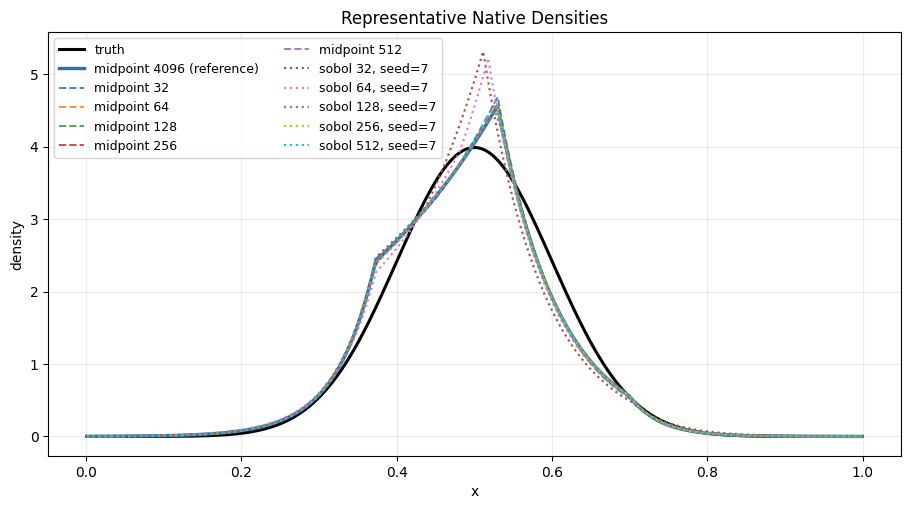

In [13]:

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(fine_grid, true_density_fine, color="black", lw=2.2, label="truth")
ax.plot(
    fine_grid,
    reference_density_fine,
    color="tab:blue",
    lw=2.4,
    label=f"midpoint {CONFIG['reference_grid_points']} (reference)",
)

for budget in CONFIG["budgets"]:
    ax.plot(
        fine_grid,
        rep_metrics_table.loc[rep_metrics_table["label"] == f"midpoint_{budget}", "native_density_fine"].iloc[0],
        ls="--",
        lw=1.4,
        alpha=0.85,
        label=f"midpoint {budget}",
    )

for budget in CONFIG["budgets"]:
    ax.plot(
        fine_grid,
        rep_metrics_table.loc[rep_metrics_table["label"] == f"sobol_{budget}_seed{CONFIG['representative_seed']}", "native_density_fine"].iloc[0],
        ls=":",
        lw=1.6,
        alpha=0.95,
        label=f"sobol {budget}, seed={CONFIG['representative_seed']}",
    )

ax.set_title("Representative Native Densities")
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=9)
plt.show()



## Sobol Bank Sensitivity Study (50 Repetitions)

The next block varies **only** the Sobol scramble seed on the same fixed dataset. It measures bank sensitivity, not dataset-level Monte Carlo variability.


In [7]:

robust_rows = []

for budget in CONFIG["budgets"]:
    for seed in CONFIG["rep_seeds"]:
        fit = fit_sobol_cvx(
            b_train=b_train,
            knots=knots,
            basis_order=CONFIG["basis_order"],
            norm_constraint=CONFIG["norm_constraint"],
            budget=budget,
            scramble_seed=seed,
            solver=CONFIG["solver"],
            use_secondary_solver=CONFIG["use_secondary_solver"],
            solver_waterfall=CONFIG["solver_waterfall"],
            theta_tol=CONFIG["theta_tol"],
        )
        metrics = compute_fit_metrics(
            fit=fit,
            b_valid=b_valid,
            b_fine=b_fine,
            fine_grid=fine_grid,
            true_density_fine=true_density_fine,
            reference_density_fine=reference_density_fine,
            reference_valid_ll=reference_valid_ll,
        )
        robust_rows.append({
            "budget": budget,
            "seed": seed,
            "used_solver": fit["used_solver"],
            "n_selected_knots": int(fit["grid_points_hal_selected"].size),
            **metrics,
        })

robust_df = pd.DataFrame(robust_rows).sort_values(["budget", "seed"])
robust_df.head()


,budget,seed,used_solver,n_selected_knots,logZ_native,logZ_ref,abs_logZ_native_minus_ref,native_density_fine,ref_density_fine,heldout_avg_loglik_native,heldout_ll_gap_to_midpoint_4096,native_normalization_residual,fine_grid_mass,iad_to_midpoint_4096,secondary_iae_to_truth,nonnegative_native_density_on_fine_grid,heldout_loglik_is_finite
0,32,0,ECOS,6,1.480977,1.493495,0.012518,"[0.0016485640034033385, 0.001651833096313648, ...","[0.0016280556777261465, 0.001631284102744924, ...",0.876930,0.005909,2.220446e-16,1.012597,0.037712,0.144839,True,True
1,32,1,ECOS,8,1.697927,1.747943,0.050017,"[0.001069088719784945, 0.0010713181234933478, ...","[0.0010169318119040245, 0.0010190524512024243,...",0.912199,0.041178,0.000000e+00,1.051289,0.169343,0.161880,True,True
2,32,2,ECOS,10,1.164580,1.146075,0.018506,"[0.0030970580556660843, 0.003102530878238231, ...","[0.003154904781400925, 0.003160479825132842, 0...",0.845525,0.025497,2.220446e-16,0.981665,0.053746,0.144294,True,True
3,32,3,ECOS,7,1.908791,1.974995,0.066204,"[0.0007027227965253645, 0.0007043128959830719,...","[0.0006577063183444192, 0.000659194555904523, ...",0.920704,0.049683,1.110223e-16,1.068445,0.114750,0.187726,True,True
4,32,4,ECOS,6,1.500782,1.505890,0.005107,"[0.001584697455239747, 0.0015878641010361372, ...","[0.0015766244431175554, 0.0015797749568946654,...",0.869487,0.001534,0.000000e+00,1.005120,0.095848,0.148861,True,True



## Summary Tables

- The first table is the deterministic summary for midpoint and representative-seed Sobol fits.
- The second table summarizes the 50 Sobol repetitions by budget using mean, median, 10th percentile, and 90th percentile.


In [8]:


def q10(x):
    return float(np.quantile(np.asarray(x, dtype=float), 0.10))


def q90(x):
    return float(np.quantile(np.asarray(x, dtype=float), 0.90))


sobol_summary = (
    robust_df.groupby("budget")[[
        "heldout_ll_gap_to_midpoint_4096",
        "iad_to_midpoint_4096",
        "abs_logZ_native_minus_ref",
        "fine_grid_mass",
        "native_normalization_residual",
    ]]
    .agg(["mean", "median", q10, q90])
)

sobol_summary


heldout_ll_gap_to_midpoint_4096                               iad_to_midpoint_4096                               abs_logZ_native_minus_ref                               fine_grid_mass  \
                                  mean    median       q10       q90                 mean    median       q10       q90                      mean    median       q10       q90           mean   
budget                                                                                                                                                                                           
32                            0.023484  0.017502  0.007343  0.044926             0.109841  0.108534  0.057243  0.176968                  0.034408  0.026395  0.008664  0.067461       1.034564   
64                            0.007514  0.005272  0.001459  0.012218             0.038398  0.038622  0.018657  0.059313                  0.009483  0.007522  0.001446  0.014869       1.008908   
128                           0.001896  0.001378  0.000325  0.004425             0.017706  0.017242  0.005846  0.028243                  0.001889  0.001444  0.000244  0.004971       1.001251   
256                           0.000513  0.000272  0.000051  0.001245             0.007344  0.006481  0.002400  0.012744                  0.000529  0.000329  0.000063  0.001390       1.000326   
512                           0.000142  0.000099  0.000013  0.000241             0.002181  0.001703  0.000714  0.004954                  0.000125  0.000090  0.000018  0.000193       1.000074   

                                     native_normalization_residual                                            
          median       q10       q90                          mean        median           q10           q90  
budget                                                                                                        
32      1.026747  1.007198  1.069788                  8.659740e-17  0.000000e+00  0.000000e+00  2.220446e-16  
64      1.007550  1.000040  1.014980                  3.375078e-16  3.330669e-16  1.110223e-16  4.551914e-16  
128     1.001126  0.999845  1.003114                  3.375078e-16  3.330669e-16  2.109424e-16  4.551914e-16  
256     1.000249  0.999733  1.000741                  2.775558e-16  2.220446e-16  0.000000e+00  6.661338e-16  
512     1.000027  0.999905  1.000191                  2.065015e-16  2.220446e-16  0.000000e+00  4.440892e-16


## Budget-vs-Gap Comparison

These are the main approximation-quality plots:

- midpoint uses one deterministic curve per budget
- Sobol uses the mean gap across 50 scrambles, with a 10th/90th percentile ribbon


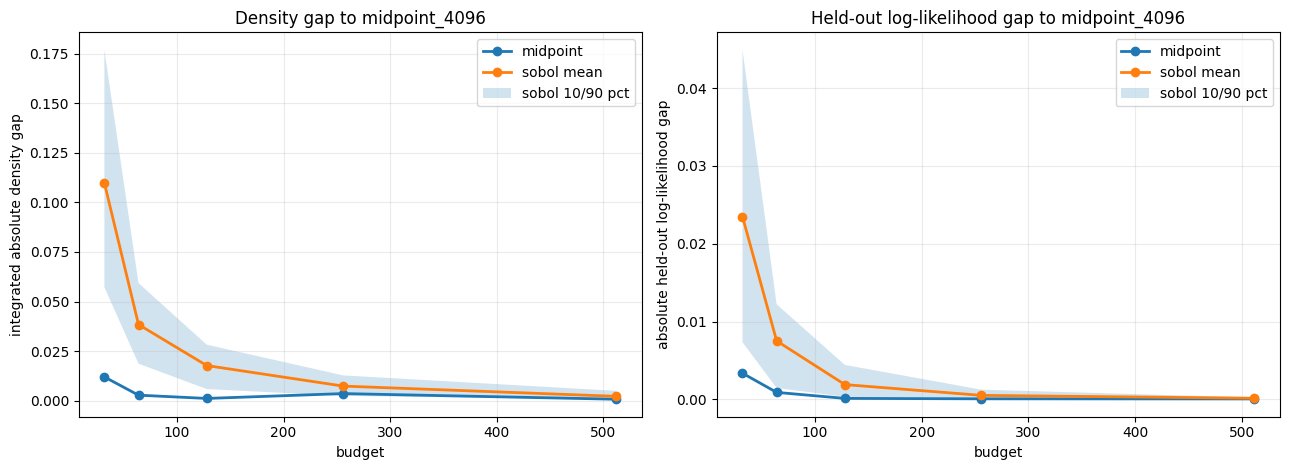

In [9]:

midpoint_curve = rep_metrics_table[
    (rep_metrics_table["model_family"] == "midpoint") &
    (rep_metrics_table["budget"] != CONFIG["reference_grid_points"])
].sort_values("budget")

sobol_gap_summary = robust_df.groupby("budget").agg(
    ll_gap_mean=("heldout_ll_gap_to_midpoint_4096", "mean"),
    ll_gap_q10=("heldout_ll_gap_to_midpoint_4096", q10),
    ll_gap_q90=("heldout_ll_gap_to_midpoint_4096", q90),
    iad_mean=("iad_to_midpoint_4096", "mean"),
    iad_q10=("iad_to_midpoint_4096", q10),
    iad_q90=("iad_to_midpoint_4096", q90),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(
    midpoint_curve["budget"],
    midpoint_curve["iad_to_midpoint_4096"],
    marker="o",
    lw=2,
    label="midpoint",
)
axes[0].plot(
    sobol_gap_summary["budget"],
    sobol_gap_summary["iad_mean"],
    marker="o",
    lw=2,
    label="sobol mean",
)
axes[0].fill_between(
    sobol_gap_summary["budget"],
    sobol_gap_summary["iad_q10"],
    sobol_gap_summary["iad_q90"],
    alpha=0.2,
    label="sobol 10/90 pct",
)
axes[0].set_title("Density gap to midpoint_4096")
axes[0].set_xlabel("budget")
axes[0].set_ylabel("integrated absolute density gap")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(
    midpoint_curve["budget"],
    midpoint_curve["heldout_ll_gap_to_midpoint_4096"],
    marker="o",
    lw=2,
    label="midpoint",
)
axes[1].plot(
    sobol_gap_summary["budget"],
    sobol_gap_summary["ll_gap_mean"],
    marker="o",
    lw=2,
    label="sobol mean",
)
axes[1].fill_between(
    sobol_gap_summary["budget"],
    sobol_gap_summary["ll_gap_q10"],
    sobol_gap_summary["ll_gap_q90"],
    alpha=0.2,
    label="sobol 10/90 pct",
)
axes[1].set_title("Held-out log-likelihood gap to midpoint_4096")
axes[1].set_xlabel("budget")
axes[1].set_ylabel("absolute held-out log-likelihood gap")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()



## Concavity / Convexity Check

With fixed Sobol bank points \(z_1,\dots,z_B\), the Sobol normalizer is

\[
\log \hat Z_{	ext{sobol}}(	heta)
=
\log\left(
rac{1}{B}\sum_{b=1}^B e^{\phi(z_b)^	op	heta}
ight)
=
\operatorname{logsumexp}(A	heta) - \log B,
\]

where each row of \(A\) is \(\phi(z_b)^	op\). Since `logsumexp` is convex and affine composition preserves convexity, \(\log \hat Z_{	ext{sobol}}(	heta)\) is convex. Therefore the approximate negative log-likelihood

\[
-\sum_{i=1}^n \phi(X_i)^	op	heta + n\log \hat Z_{	ext{sobol}}(	heta)
\]

remains convex, and the usual `L1` feasible set preserves a convex program.


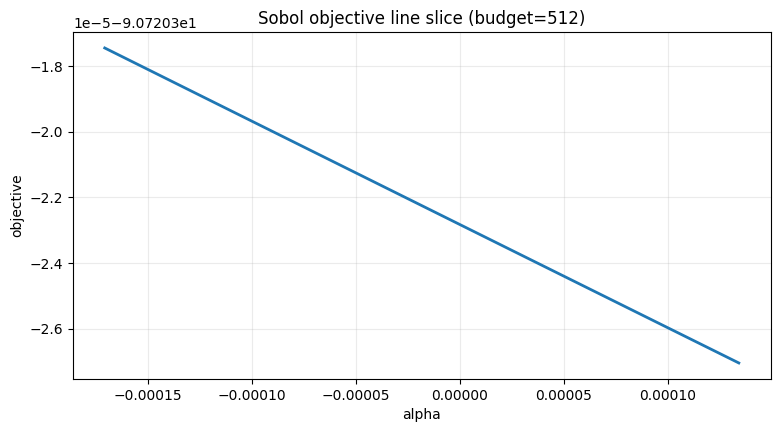

feasible points: 26 / 161, scale used: 9.77e-04
minimum second difference (diagnostic): 5.697131655324483e-11


In [10]:

slice_budget = 512
slice_fit = sobol_rep_fits[slice_budget]
theta0 = np.asarray(slice_fit["theta_hat"], dtype=float)
b_train_slice = b_train
b_norm_slice = np.asarray(slice_fit["b_norm"], dtype=float)

rng_slice = np.random.default_rng(2026)
dir_vec = rng_slice.normal(size=theta0.size)
dir_vec[0] = 0.0
if np.linalg.norm(dir_vec) == 0.0:
    dir_vec = np.zeros_like(theta0)
    dir_vec[1] = 1.0
dir_vec = dir_vec / np.linalg.norm(dir_vec)


def eval_line_slice(scale: float):
    alphas_local = np.linspace(-1.0, 1.0, 161) * scale
    obj_local = []
    for a in alphas_local:
        th = theta0 + a * dir_vec
        if np.sum(np.abs(th[1:])) > CONFIG["norm_constraint"]:
            obj_local.append(np.nan)
            continue
        first_term = -np.sum(b_train_slice @ th)
        logz_term = logsumexp(b_norm_slice @ th) - np.log(slice_budget)
        obj_local.append(float(first_term + b_train_slice.shape[0] * logz_term))
    obj_local = np.asarray(obj_local)
    mask_local = np.isfinite(obj_local)
    return alphas_local, obj_local, mask_local


scale = 1.0
alphas, obj_vals, mask = eval_line_slice(scale)
while mask.sum() < 21 and scale > 1e-6:
    scale *= 0.5
    alphas, obj_vals, mask = eval_line_slice(scale)

if mask.sum() < 3:
    dir_vec = np.zeros_like(theta0)
    dir_vec[0] = 1.0
    alphas, obj_vals, mask = eval_line_slice(1.0)

fig, ax = plt.subplots(figsize=(9, 4.5))
if mask.any():
    ax.plot(alphas[mask], obj_vals[mask], lw=2)
else:
    ax.text(0.5, 0.5, "No feasible points found", ha="center", va="center", transform=ax.transAxes)
ax.set_title(f"Sobol objective line slice (budget={slice_budget})")
ax.set_xlabel("alpha")
ax.set_ylabel("objective")
ax.grid(alpha=0.25)
plt.show()

print(f"feasible points: {int(mask.sum())} / {mask.size}, scale used: {scale:.2e}")
if mask.sum() >= 3:
    second_diff = np.diff(obj_vals[mask], n=2)
    print("minimum second difference (diagnostic):", float(np.min(second_diff)))



## Validity Checks and Conclusion

The validity checks below use:

- method-native normalization residuals,
- fine-grid mass on the common Lebesgue grid,
- nonnegativity and finite held-out log-likelihood.

The conclusion emphasizes gap to `midpoint_4096` and uses truth only as secondary context.


In [11]:

validity_table = rep_metrics_table[[
    "label",
    "model_family",
    "budget",
    "seed",
    "native_normalization_residual",
    "fine_grid_mass",
    "heldout_avg_loglik_native",
    "heldout_ll_gap_to_midpoint_4096",
    "iad_to_midpoint_4096",
    "abs_logZ_native_minus_ref",
    "secondary_iae_to_truth",
    "nonnegative_native_density_on_fine_grid",
    "heldout_loglik_is_finite",
]].copy()

validity_table["fine_grid_mass_in_[0.95,1.05]"] = validity_table["fine_grid_mass"].between(0.95, 1.05)
validity_table["native_norm_residual_small"] = validity_table["native_normalization_residual"] < 1e-8
validity_table


,label,model_family,budget,seed,native_normalization_residual,fine_grid_mass,heldout_avg_loglik_native,heldout_ll_gap_to_midpoint_4096,iad_to_midpoint_4096,abs_logZ_native_minus_ref,secondary_iae_to_truth,nonnegative_native_density_on_fine_grid,heldout_loglik_is_finite,"fine_grid_mass_in_[0.95,1.05]",native_norm_residual_small
1,midpoint_32,midpoint,32,NaN,0.000000e+00,1.004823,0.874380,0.003359,0.011975,0.004811,0.119908,True,True,True,True
2,midpoint_64,midpoint,64,NaN,3.330669e-16,1.001052,0.871918,0.000896,0.002776,0.001052,0.112233,True,True,True,True
3,midpoint_128,midpoint,128,NaN,2.220446e-16,1.000111,0.871145,0.000124,0.001121,0.000111,0.111739,True,True,True,True
4,midpoint_256,midpoint,256,NaN,3.330669e-16,1.000012,0.870952,0.000069,0.003571,0.000012,0.112133,True,True,True,True
5,midpoint_512,midpoint,512,NaN,3.330669e-16,1.000010,0.871078,0.000056,0.000726,0.000010,0.111602,True,True,True,True
0,midpoint_4096_reference,midpoint,4096,NaN,1.110223e-15,0.999998,0.871021,0.000000,0.000000,0.000002,0.111834,True,True,True,True
6,sobol_32_seed7,sobol,32,7.0,2.220446e-16,1.022682,0.883886,0.012864,0.084342,0.022429,0.162694,True,True,True,True
7,sobol_64_seed7,sobol,64,7.0,3.330669e-16,1.013089,0.880529,0.009507,0.049714,0.013004,0.128932,True,True,True,True
8,sobol_128_seed7,sobol,128,7.0,0.000000e+00,1.001512,0.872708,0.001687,0.008352,0.001511,0.109446,True,True,True,True
9,sobol_256_seed7,sobol,256,7.0,3.330669e-16,1.000420,0.871201,0.000180,0.006933,0.000420,0.113050,True,True,True,True


In [12]:

from IPython.display import Markdown, display

all_det_valid = bool(
    np.all(validity_table["nonnegative_native_density_on_fine_grid"]) and
    np.all(validity_table["heldout_loglik_is_finite"]) and
    np.all(validity_table["fine_grid_mass_in_[0.95,1.05]"]) and
    np.all(validity_table["native_norm_residual_small"])
)

sobol_rep_valid = bool(
    np.all(robust_df["nonnegative_native_density_on_fine_grid"]) and
    np.all(robust_df["heldout_loglik_is_finite"]) and
    np.all(robust_df["fine_grid_mass"].between(0.95, 1.05)) and
    np.all(robust_df["native_normalization_residual"] < 1e-8)
)

midpoint_gap = midpoint_curve[["budget", "heldout_ll_gap_to_midpoint_4096", "iad_to_midpoint_4096"]].set_index("budget")
sobol_comp = sobol_gap_summary.set_index("budget")

sobol_mean_better_iad = [int(b) for b in sobol_comp.index if sobol_comp.loc[b, "iad_mean"] <= midpoint_gap.loc[b, "iad_to_midpoint_4096"]]
sobol_mean_better_ll = [int(b) for b in sobol_comp.index if sobol_comp.loc[b, "ll_gap_mean"] <= midpoint_gap.loc[b, "heldout_ll_gap_to_midpoint_4096"]]
sobol_q90_better_iad = [int(b) for b in sobol_comp.index if sobol_comp.loc[b, "iad_q90"] <= midpoint_gap.loc[b, "iad_to_midpoint_4096"]]

conclusion_md = f"""
**Short conclusion**

- Deterministic fits valid on this fixed dataset: **{'yes' if all_det_valid else 'no'}**.
- All 50-repetition Sobol bank runs valid on this fixed dataset: **{'yes' if sobol_rep_valid else 'no'}**.
- Budgets where Sobol **mean** density gap to `midpoint_4096` beats or matches midpoint at the same budget: **{sobol_mean_better_iad or 'none'}**.
- Budgets where Sobol **mean** held-out log-likelihood gap beats or matches midpoint at the same budget: **{sobol_mean_better_ll or 'none'}**.
- Budgets where Sobol **90th percentile** density gap beats or matches midpoint at the same budget: **{sobol_q90_better_iad or 'none'}**.

This notebook is a **bank-sensitivity study on one fixed dataset**. If Sobol remains competitive by the mean and upper-quantile gap metrics at larger budgets, that supports a phase-2 package prototype.

Truth-based error is retained only as external context; the main numerical benchmark here is the high-resolution `midpoint_4096` fit.
"""

display(Markdown(conclusion_md))



**Short conclusion**

- Deterministic fits valid on this fixed dataset: **yes**.
- All 50-repetition Sobol bank runs valid on this fixed dataset: **no**.
- Budgets where Sobol **mean** density gap to `midpoint_4096` beats or matches midpoint at the same budget: **none**.
- Budgets where Sobol **mean** held-out log-likelihood gap beats or matches midpoint at the same budget: **none**.
- Budgets where Sobol **90th percentile** density gap beats or matches midpoint at the same budget: **none**.

This notebook is a **bank-sensitivity study on one fixed dataset**. If Sobol remains competitive by the mean and upper-quantile gap metrics at larger budgets, that supports a phase-2 package prototype.

Truth-based error is retained only as external context; the main numerical benchmark here is the high-resolution `midpoint_4096` fit.


## Clearer Midpoint vs Sobol Native Density Plot

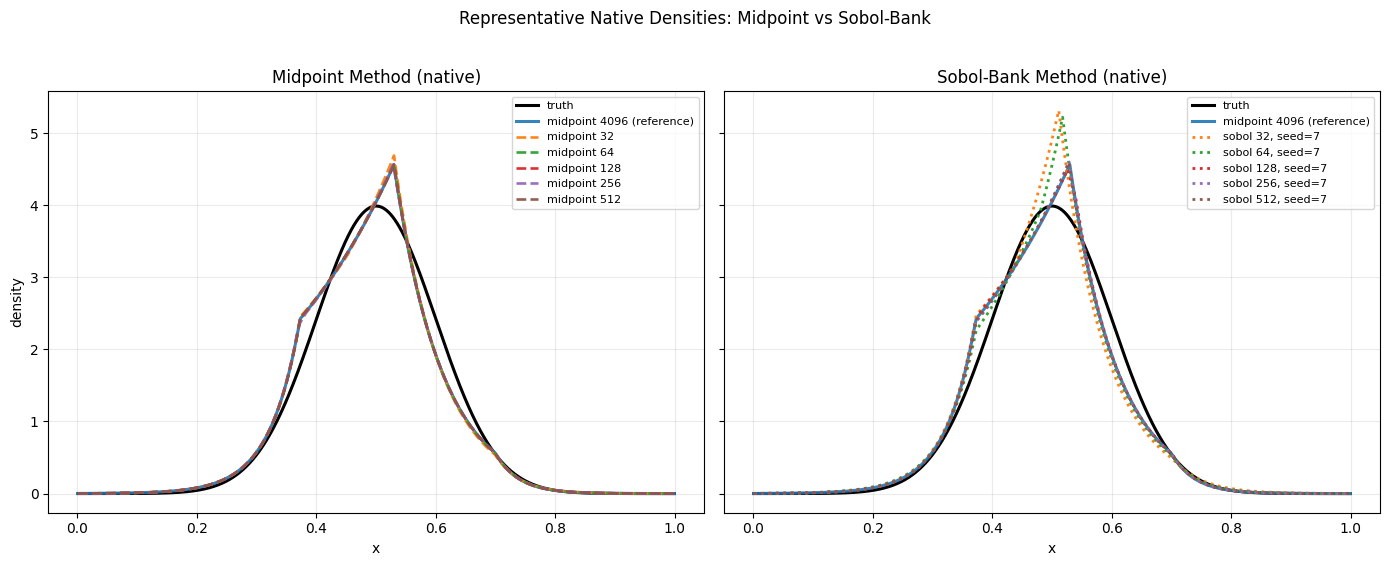

In [16]:
# Clear method separation: midpoint family (left) vs Sobol-bank family (right).
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)
ax_mid, ax_sob = axes

for ax in axes:
    ax.plot(fine_grid, true_density_fine, color="black", lw=2.2, label="truth")
    ax.plot(
        fine_grid,
        reference_density_fine,
        color="tab:blue",
        lw=2.2,
        alpha=0.9,
        label=f"midpoint {CONFIG['reference_grid_points']} (reference)",
    )

# Keep same color for each budget across both methods.
palette = ["tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink"]
budget_colors = {b: palette[i % len(palette)] for i, b in enumerate(CONFIG["budgets"])}

for budget in CONFIG["budgets"]:
    ax_mid.plot(
        fine_grid,
        rep_metrics_table.loc[rep_metrics_table["label"] == f"midpoint_{budget}", "native_density_fine"].iloc[0],
        color=budget_colors[budget],
        ls="--",
        lw=1.9,
        alpha=0.95,
        label=f"midpoint {budget}",
    )

for budget in CONFIG["budgets"]:
    ax_sob.plot(
        fine_grid,
        rep_metrics_table.loc[rep_metrics_table["label"] == f"sobol_{budget}_seed{CONFIG['representative_seed']}", "native_density_fine"].iloc[0],
        color=budget_colors[budget],
        ls=":",
        lw=2.0,
        alpha=0.98,
        label=f"sobol {budget}, seed={CONFIG['representative_seed']}",
    )

ax_mid.set_title("Midpoint Method (native)")
ax_sob.set_title("Sobol-Bank Method (native)")
for ax in axes:
    ax.set_xlabel("x")
    ax.grid(alpha=0.25)
ax_mid.set_ylabel("density")
ax_mid.legend(fontsize=8)
ax_sob.legend(fontsize=8)
fig.suptitle("Representative Native Densities: Midpoint vs Sobol-Bank", y=1.02)
fig.tight_layout()
plt.show()

The budget-matched univariate study suggests that fixed-bank Sobol normalization is not competitive with midpoint quadrature in one dimension. Although the Sobol approximation preserves convexity and yields valid fits, midpoint quadrature approaches the high-resolution reference faster and with greater stability at the same budget. This is consistent with deterministic quadrature being unusually favorable in low dimension. The main motivation for Sobol-type approximations therefore remains multivariate HAL settings, where dense midpoint grids stop scaling, rather than improving univariate performance.